In [5]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Fitted function: E = 0.002044 + 7.120556e-06 * pt
R-squared: 0.756319
Standard error of slope: 7.778407e-07


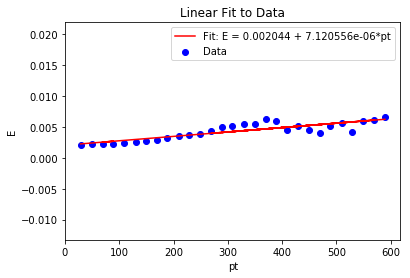

In [6]:
# Data
pt = np.array([589.12656, 369.51872, 388.77005, 549.19786, 569.16221, 509.26916, 349.55437, 
               328.87701, 308.19964, 428.69875, 488.5918, 288.94831, 409.44742, 449.37611, 
               268.98396, 529.23351, 469.34046, 249.01961, 228.34225, 209.09091, 188.41355, 
               169.16221, 149.19786, 129.94652, 109.26916, 69.34046, 89.30481, 49.37611, 28.69875])
E = np.array([0.00653, 0.0062, 0.00594, 0.006, 0.00607, 0.00557, 0.0054, 0.0054, 0.00517, 
              0.00517, 0.00512, 0.00496, 0.0045, 0.0045, 0.00436, 0.00423, 0.00409, 0.00392, 
              0.00368, 0.00349, 0.00324, 0.00294, 0.00279, 0.00251, 0.00235, 0.00228, 
              0.0023, 0.00226, 0.00212])

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(pt, E)

# Fitted function
E_fit = intercept + slope * pt

# Print results
print(f"Fitted function: E = {intercept:.6f} + {slope:.6e} * pt")
print(f"R-squared: {r_value**2:.6f}")
print(f"Standard error of slope: {std_err:.6e}")

# Plot data and fit
plt.scatter(pt, E, label='Data', color='blue')
plt.plot(pt, E_fit, label=f'Fit: E = {intercept:.6f} + {slope:.6e}*pt', color='red')
plt.xlabel('pt')
plt.ylabel('E')
plt.legend()
plt.title('Linear Fit to Data')
plt.show()

Fitted parameters: A = 0.213913 ± 742516.813982, B = 0.019986 ± 0.004061, C = 0.003422 ± 0.000831, D = 0.947750 ± 3289745.198696
Fitted function: y = 0.214 * tanh(0.020 * x) * (0.95 / (1 + 0.003 * x))
R-squared: 0.805122


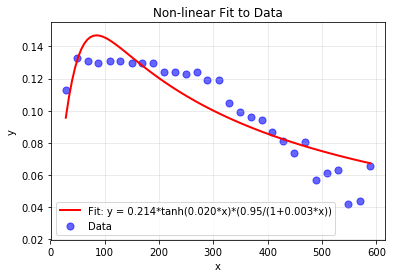


Expected function R-squared: -306.820617


In [20]:
# Data
x = np.array([49.37611, 69.34046, 109.26916, 129.23351, 149.91087, 169.16221, 189.12656, 
              88.5918, 209.09091, 229.05526, 249.01961, 269.69697, 288.94831, 309.62567, 
              28.69875, 328.87701, 348.84135, 368.8057, 389.48307, 408.7344, 428.69875, 
              468.62745, 448.6631, 588.41355, 529.23351, 508.55615, 488.5918, 569.16221, 
              547.77184])
y = np.array([0.13256, 0.13115, 0.13115, 0.13115, 0.12977, 0.12977, 0.12977, 0.12977, 
              0.12436, 0.12436, 0.12305, 0.12436, 0.11918, 0.11918, 0.11301, 0.1049, 
              0.09947, 0.09635, 0.09432, 0.08663, 0.08127, 0.08041, 0.07385, 0.0657, 
              0.06296, 0.06098, 0.05661, 0.04386, 0.04203])

# # Define the fitting function
# def fit_func(x, A, B, C):
#     return A * np.tanh(B * x) / (1 + C * x)

# # Initial guess for parameters [A, B, C]
# initial_guess = [0.20, 0.02, 0.0034]

# # Perform the curve fit
# popt, pcov = curve_fit(fit_func, x, y, p0=initial_guess)

# # Extract fitted parameters
# A, B, C = popt

# # Calculate the fitted y values
# y_fit = fit_func(x, A, B, C)

# # Calculate R-squared
# residuals = y - y_fit
# ss_res = np.sum(residuals**2)
# ss_tot = np.sum((y - np.mean(y))**2)
# r_squared = 1 - (ss_res / ss_tot)

# # Print results
# print(f"Fitted parameters: A = {A:.6f}, B = {B:.6f}, C = {C:.6f}")
# print(f"R-squared: {r_squared:.6f}")

# # Plot data and fit
# plt.scatter(x, y, label='Data', color='blue')
# # Sort x for smooth curve
# x_smooth = np.linspace(min(x), max(x), 100)
# y_smooth = fit_func(x_smooth, A, B, C)
# plt.plot(x_smooth, y_smooth, label=f'Fit: y = {A:.3f}*tanh({B:.3f}*x)/(1 + {C:.4f}*x)', color='red')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.legend()
# plt.title('Non-linear Fit to Data')
# plt.show()

def fit_func(x, A, B, C, D):
    return A * np.tanh(B * x) * (D / (1 + C * x))

# Initial guess for parameters [A, B, C, D] based on expected form
initial_guess = [0.20, 0.02, 0.0034, 1]

# Perform the curve fit
popt, pcov = curve_fit(fit_func, x, y, p0=initial_guess)

# Extract fitted parameters
A, B, C, D = popt

# Calculate standard errors of parameters
perr = np.sqrt(np.diag(pcov))

# Calculate the fitted y values
y_fit = fit_func(x, A, B, C, D)

# Calculate R-squared
residuals = y - y_fit
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)

# Print results
print(f"Fitted parameters: A = {A:.6f} ± {perr[0]:.6f}, B = {B:.6f} ± {perr[1]:.6f}, "
      f"C = {C:.6f} ± {perr[2]:.6f}, D = {D:.6f} ± {perr[3]:.6f}")
print(f"Fitted function: y = {A:.3f} * tanh({B:.3f} * x) * ({D:.2f} / (1 + {C:.3f} * x))")
print(f"R-squared: {r_squared:.6f}")

# Plot data and fit
plt.scatter(x, y, label='Data', color='blue', s=50, alpha=0.6)
# Sort x for smooth curve
x_smooth = np.linspace(min(x), max(x), 100)
y_smooth = fit_func(x_smooth, A, B, C, D)
plt.plot(x_smooth, y_smooth, label=f'Fit: y = {A:.3f}*tanh({B:.3f}*x)*({D:.2f}/(1+{C:.3f}*x))', 
         color='red', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Non-linear Fit to Data')
plt.grid(True, alpha=0.3)
plt.show()

# Compare with expected function
y_expected = 0.80 * np.tanh(0.003 * x) * (30 / (1 + 0.086 * x))
residuals_expected = y - y_expected
ss_res_expected = np.sum(residuals_expected**2)
r_squared_expected = 1 - (ss_res_expected / ss_tot)
print(f"\nExpected function R-squared: {r_squared_expected:.6f}")

Fitted parameters: A = 0.697105 ± 443212.744373, B = 0.003294 ± 0.000089, C = 0.065096 ± 0.006696, D = 25.512096 ± 16214839.919661
Fitted function: y = 0.697 * tanh(0.003 * x) * (25.51 / (1 + 0.065 * x))
R-squared: 0.987448


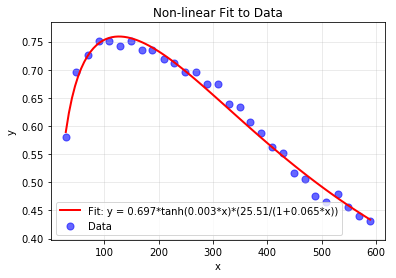


Expected function R-squared: 0.966573


In [11]:
# Data
x = np.array([90.73084, 109.26916, 149.19786, 188.41355, 169.87522, 129.23351, 69.34046, 
              209.09091, 228.34225, 249.01961, 268.27094, 48.6631, 289.66132, 309.62567, 
              328.87701, 349.55437, 368.8057, 388.77005, 29.41176, 409.44742, 427.98574, 
              449.37611, 469.34046, 529.23351, 488.5918, 508.55615, 549.19786, 569.16221, 
              589.12656])
y = np.array([0.75039, 0.75039, 0.75039, 0.7346, 0.7346, 0.74245, 0.72683, 0.71914, 
              0.71153, 0.69656, 0.69656, 0.69656, 0.67468, 0.67468, 0.63974, 0.63297, 
              0.60661, 0.58756, 0.58135, 0.56309, 0.55124, 0.51716, 0.50628, 0.48006, 
              0.47498, 0.46498, 0.4552, 0.4409, 0.43162])

# Define the fitting function: y = A * tanh(B * x) * (D / (1 + C * x))
def fit_func(x, A, B, C, D):
    return A * np.tanh(B * x) * (D / (1 + C * x))

# Initial guess for parameters [A, B, C, D] based on expected form
initial_guess = [0.80, 0.003, 0.086, 30]

# Perform the curve fit
popt, pcov = curve_fit(fit_func, x, y, p0=initial_guess)

# Extract fitted parameters
A, B, C, D = popt

# Calculate standard errors of parameters
perr = np.sqrt(np.diag(pcov))

# Calculate the fitted y values
y_fit = fit_func(x, A, B, C, D)

# Calculate R-squared
residuals = y - y_fit
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)

# Print results
print(f"Fitted parameters: A = {A:.6f} ± {perr[0]:.6f}, B = {B:.6f} ± {perr[1]:.6f}, "
      f"C = {C:.6f} ± {perr[2]:.6f}, D = {D:.6f} ± {perr[3]:.6f}")
print(f"Fitted function: y = {A:.3f} * tanh({B:.3f} * x) * ({D:.2f} / (1 + {C:.3f} * x))")
print(f"R-squared: {r_squared:.6f}")

# Plot data and fit
plt.scatter(x, y, label='Data', color='blue', s=50, alpha=0.6)
# Sort x for smooth curve
x_smooth = np.linspace(min(x), max(x), 100)
y_smooth = fit_func(x_smooth, A, B, C, D)
plt.plot(x_smooth, y_smooth, label=f'Fit: y = {A:.3f}*tanh({B:.3f}*x)*({D:.2f}/(1+{C:.3f}*x))', 
         color='red', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Non-linear Fit to Data')
plt.grid(True, alpha=0.3)
plt.show()

# Compare with expected function
y_expected = 0.80 * np.tanh(0.003 * x) * (30 / (1 + 0.086 * x))
residuals_expected = y - y_expected
ss_res_expected = np.sum(residuals_expected**2)
r_squared_expected = 1 - (ss_res_expected / ss_tot)
print(f"\nExpected function R-squared: {r_squared_expected:.6f}")